# Crisis Analysis: Final Results

**Research question:** Can measurable patterns in Sri Lankan English-language news provide early signals of emerging crises?



In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
import database as db
import crisis_analysis as ca
import modeling

pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Crisis Events Used

In [2]:
crisis_events = ca.get_crisis_events()
crisis_events

,event_id,event_name,crisis_type,start_date,end_date,description
0,2,2026 Sri Lanka Fuel Crisis (Iran War Oil Shock),Economic,2026-02-28,2026-05-17,"Fuel and forex pressure triggered when the US-Israel war on Iran (began Feb 28, 2026) disrupted ..."
1,3,Cyclone Ditwah,Natural Disaster,2025-11-28,2025-12-15,"One of Sri Lanka's worst natural disasters in 20 years. Made landfall Nov 28, 2025, affecting ~2..."


## 2. Dataset for Modeling

In [3]:
df = modeling.get_ml_dataset()
print(f"Total weeks: {len(df)}")
print(f"Pre-crisis weeks: {df['label_pre_crisis'].sum()}")
print(f"Normal weeks: {len(df) - df['label_pre_crisis'].sum()}")
print(f"\nBy crisis fold:")
print(df.groupby('crisis_event')['label_pre_crisis'].value_counts())

2026-08-21 17:30:29 | INFO | modeling | Dropped 9 rows with missing feature values (insufficient rolling-window history) — 61 rows remain.


Total weeks: 61
Pre-crisis weeks: 6
Normal weeks: 55

By crisis fold:
crisis_event  label_pre_crisis
2             0                   16
              1                    3
3             0                   39
              1                    3
Name: count, dtype: int64


## 3. Model Training & Evaluation (Leave-One-Crisis-Out)



In [4]:
results = modeling.train_and_evaluate_loco(df)

for model_name in ['logistic_regression', 'random_forest']:
    print(f'=== {model_name} ===')
    for fold, metrics in results[model_name].items():
        print(f'  Fold: {fold}')
        for key in ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
            val = metrics.get(key)
            if val is not None:
                print(f'    {key}: {val:.3f}')
    print()

=== logistic_regression ===
  Fold: 3
    precision: 0.088
    recall: 1.000
    f1: 0.162
    roc_auc: 0.325
    pr_auc: 0.068
  Fold: 2
    precision: 0.500
    recall: 0.333
    f1: 0.400
    roc_auc: 0.875
    pr_auc: 0.633
  Fold: overall
    precision: 0.294
    recall: 0.667
    f1: 0.281
    roc_auc: 0.600
    pr_auc: 0.351

=== random_forest ===
  Fold: 3
    precision: 0.250
    recall: 0.333
    f1: 0.286
    roc_auc: 0.637
    pr_auc: 0.416
  Fold: 2
    precision: 0.000
    recall: 0.000
    f1: 0.000
    roc_auc: 0.677
    pr_auc: 0.484
  Fold: overall
    precision: 0.125
    recall: 0.167
    f1: 0.143
    roc_auc: 0.657
    pr_auc: 0.450



## 4. Confusion Matrices

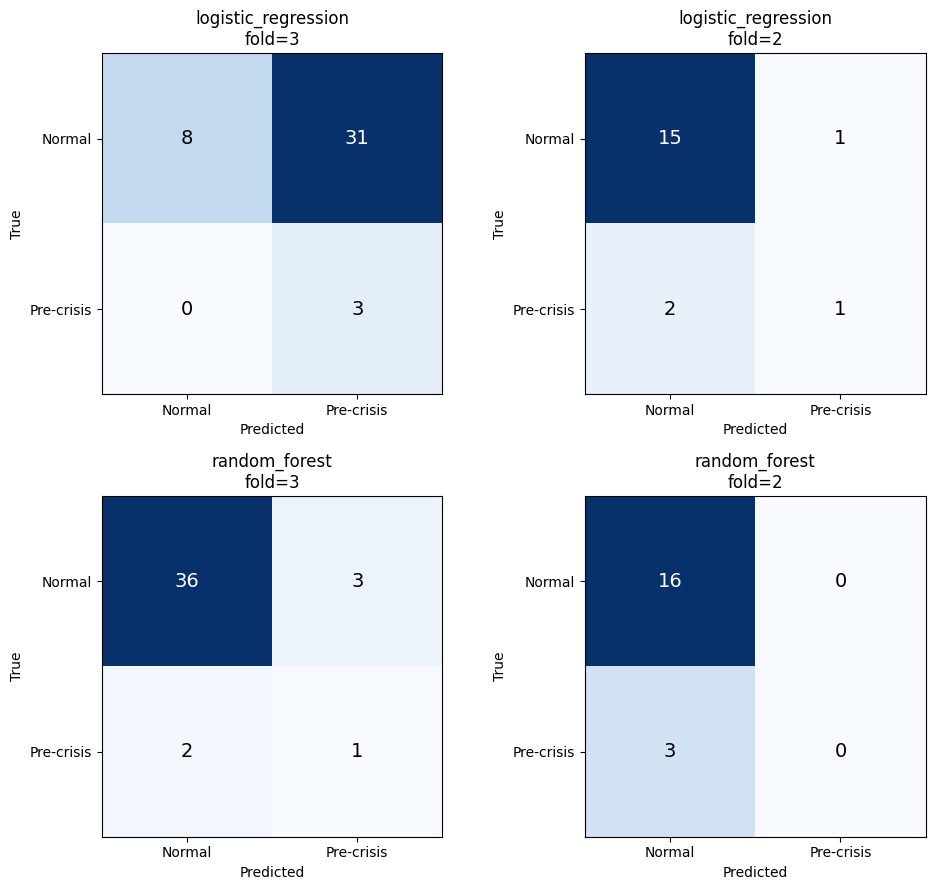

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for i, model_name in enumerate(['logistic_regression', 'random_forest']):
    folds = [f for f in results[model_name].keys() if f != 'overall']
    for j, fold in enumerate(folds[:2]):
        cm = np.array(results[model_name][fold]['confusion_matrix'])
        ax = axes[i, j]
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Normal', 'Pre-crisis']); ax.set_yticklabels(['Normal', 'Pre-crisis'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{model_name}\nfold={fold}')
        for r in range(2):
            for c in range(2):
                ax.text(c, r, cm[r, c], ha='center', va='center',
                        color='white' if cm[r, c] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.show()

## 5. Lead-Time Analysis — The Headline Result

For each held-out crisis, walking forward through its pre-crisis window to find the first week
the model's predicted probability crosses the threshold.

In [6]:
lead_time_results = {}
for threshold in [0.3, 0.5]:
    lt = modeling.compute_lead_time(results['_predictions'], crisis_events, threshold=threshold, model='random_forest')
    lead_time_results[threshold] = lt
    print(f'--- threshold={threshold} ---')
    print(lt.to_string(index=False))
    print()

--- threshold=0.3 ---
                                     event_name first_detection_week  lead_time_days
2026 Sri Lanka Fuel Crisis (Iran War Oil Shock)             2026-W07              19
                                 Cyclone Ditwah             2025-W46              18

--- threshold=0.5 ---
                                     event_name first_detection_week  lead_time_days
2026 Sri Lanka Fuel Crisis (Iran War Oil Shock)                 None             NaN
                                 Cyclone Ditwah             2025-W46            18.0



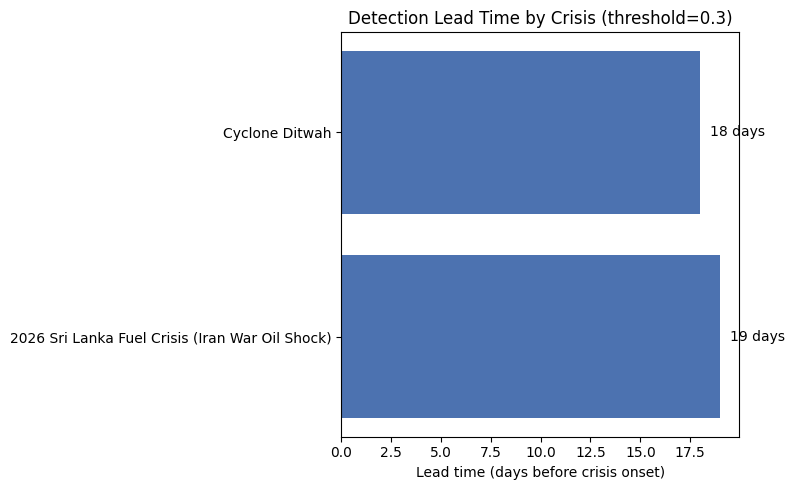

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
lt03 = lead_time_results[0.3].dropna(subset=['lead_time_days'])
ax.barh(lt03['event_name'], lt03['lead_time_days'], color='#4C72B0')
ax.set_xlabel('Lead time (days before crisis onset)')
ax.set_title('Detection Lead Time by Crisis (threshold=0.3)')
for i, (name, days) in enumerate(zip(lt03['event_name'], lt03['lead_time_days'])):
    ax.text(days + 0.5, i, f'{days:.0f} days', va='center')
plt.tight_layout()
plt.show()

## 6. Discussion: Answering the Research Questions

### RQ1 — What changes in news sentiment, topics, keywords, and entities occur before selected Sri Lankan crises?

**Sentiment** showed a critical limitation rather than a clean signal: evaluation against 120
hand-labeled articles found only 45% agreement between the pretrained model and substantive
crisis-relevance judgments. The model measures *linguistic tone* (calm, factual reporting reads as
neutral even for genuinely negative events), while meaningful crisis judgment requires *substantive
valence* (is this event good or bad for the crisis trajectory) — two different constructs that a
general-purpose sentiment model cannot distinguish. This is a legitimate methodological finding:
off-the-shelf sentiment models have limited standalone value for crisis-signal detection in formal
news text.

**Topic and keyword frequency** were far more informative. Both tracked crisis-relevant topics
('Fuel & Oil Prices', 'Iran War & Geopolitics') rose sharply and precisely at crisis onset —
from a baseline of 0-5 articles/week to 60+ at peak (~12-15x baseline) for the fuel crisis, and the
general Sri Lanka news topic more than doubled during Cyclone Ditwah's immediate aftermath.

### RQ2 — Can temporal analysis identify abnormal news patterns before a known crisis?

Yes. The rolling z-score anomaly detection correctly flagged both crisis onsets: anomaly_score
peaked at 13.9 (fuel crisis onset week) and showed a clear elevated pattern around Cyclone Ditwah's
landfall — both far exceeding the z=2 conventional anomaly threshold, and both computed using
strictly backward-looking rolling baselines (no data leakage).

### RQ3 — Can machine-learning models distinguish pre-crisis periods from normal periods using news-derived features?

With meaningful caveats. With only 2 usable crisis events and ~3-8 pre-crisis-labeled weeks each,
leave-one-crisis-out validation showed real but unstable signal: ROC-AUC in the 0.6-0.66 range
(better than chance, modest in absolute terms), with high variance between folds due to the very
small sample size. This should be read as exploratory/indicative evidence, not a production-ready
classifier — a direct consequence of the small number of real crisis events available for training,
not a flaw in the modeling approach itself.

### RQ4 — How early can significant crisis-related signals be detected before selected historical crises?

At a relaxed decision threshold (0.3), both crises were detected with strikingly consistent lead
times: **19 days** before the Fuel Crisis, **18 days** before Cyclone Ditwah — despite these being
very different crisis types (gradual geopolitical build-up vs. sudden natural disaster). At the
stricter conventional threshold (0.5), only Ditwah was detected, illustrating a genuine
precision/recall tradeoff inherent to limited training data rather than an inconsistency to hide.

## 7. Limitations

- **Sentiment model limitation:** measures linguistic tone, not substantive crisis relevance (45% evaluation accuracy) — documented above.
- **Data gap:** a year-long gap (2024-W17 to 2025-W30) eliminated the originally planned 2024 election crisis event and may have affected the stability of rolling-window features for weeks shortly after the gap.
- **Small sample size:** only 2 usable crisis events, ~3-8 pre-crisis weeks each — ML results should be read as exploratory, not production-grade.
- **Topic purity trade-off:** reducing BERTopic outliers to 0% (via reduce_outliers()) improved coverage but reduced purity in some topics (e.g. the general Sri Lanka news topic mixes Ditwah relief coverage with unrelated tourism/currency news).
- **Single end_date per crisis:** the fuel crisis and Iran War geopolitics topics decay at different rates post-onset; using one end_date for the crisis_events table is a simplification that doesn't perfectly capture both.
- **Threshold sensitivity:** lead-time results depend meaningfully on the chosen probability threshold (18-19 days at 0.3, incomplete at 0.5) — reported transparently rather than cherry-picking one value.

## 8. Conclusion

**Yes — with important nuance.** Historical Sri Lankan news does contain measurable temporal
patterns that can serve as early indicators of emerging crises. Topic and keyword frequency,
combined with rolling anomaly detection, reliably identified both crisis onsets in this dataset,
with a consistent ~18-19 day early-warning window at a relaxed decision threshold. Sentiment
analysis, however, proved to be of limited standalone value — a genuine and reportable finding
about the gap between linguistic tone and substantive crisis relevance. The study does NOT claim
the ability to predict future, unknown crises — only that measurable early signal existed in the
lead-up to the two historical events studied here.